<a href="https://colab.research.google.com/github/rafiafsan/Atlas-Voice-Assistant/blob/main.py/eeg_cnn_csvhb_mit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
subirbiswas19_eeg_dataset_path = kagglehub.dataset_download('subirbiswas19/eeg-dataset')

print('Data source import complete.')


In [ ]:
import pandas as pd

# Replace with your actual file path and name
file_path = "/kaggle/input/eeg-dataset/EEG_Scaled_data.csv"

# Read the CSV into a DataFrame
df = pd.read_csv(file_path)

# Show the first 5 rows
print(df.head())


   Channel_1  Channel_2  Channel_3  Channel_4  Channel_5  Channel_6  \
0      0.647      0.149     -0.213     -0.199     -0.287     -0.187   
1     -2.450     -2.788     -2.387     -1.370     -1.032     -1.037   
2     -0.026     -0.123     -0.347     -0.348      0.027      0.162   
3     -0.067     -0.153     -0.180     -0.210     -0.238     -0.183   
4     -0.190     -0.299     -0.333     -0.199      0.182      0.261   

   Channel_7  Channel_8  Channel_9  Channel_10  ...  Channel_36856  \
0      0.320      0.445      0.482       0.348  ...          0.076   
1     -1.253     -1.702     -2.116      -2.019  ...          0.154   
2      0.166     -0.045     -0.083      -0.037  ...          0.086   
3     -0.147     -0.238     -0.305      -0.187  ...         -0.101   
4      0.262     -0.075     -0.403      -0.232  ...          0.621   

   Channel_36857  Channel_36858  Channel_36859  Channel_36860  Channel_36861  \
0          0.283          0.365         -0.013         -0.029          0

In [ ]:
df.info

<bound method DataFrame.info of        Channel_1  Channel_2  Channel_3  Channel_4  Channel_5  Channel_6  \
0          0.647      0.149     -0.213     -0.199     -0.287     -0.187   
1         -2.450     -2.788     -2.387     -1.370     -1.032     -1.037   
2         -0.026     -0.123     -0.347     -0.348      0.027      0.162   
3         -0.067     -0.153     -0.180     -0.210     -0.238     -0.183   
4         -0.190     -0.299     -0.333     -0.199      0.182      0.261   
...          ...        ...        ...        ...        ...        ...   
11228     -0.956     -0.770     -0.660     -0.643     -0.752     -0.769   
11229     -0.573     -0.572     -0.578     -0.531     -0.499     -0.474   
11230     -0.123      0.097     -0.039     -0.019      0.197      0.054   
11231      0.402      0.389      0.337      0.249      0.091     -0.015   
11232      0.866      0.927      0.996      1.048      1.093      1.154   

       Channel_7  Channel_8  Channel_9  Channel_10  ...  Channel_36

In [ ]:
print("Value counts in target column:")
print(df['target'].value_counts())

Value counts in target column:
target
0    9799
1    1434
Name: count, dtype: int64


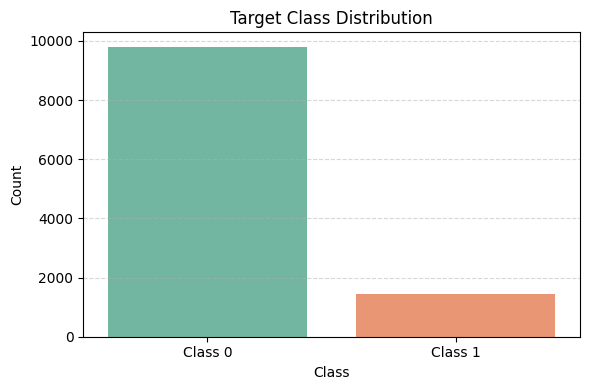

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
sns.countplot(x='target', data=df, palette='Set2')

plt.title('Target Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks([0, 1], ['Class 0', 'Class 1'])
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
original_counts = df['target'].value_counts()

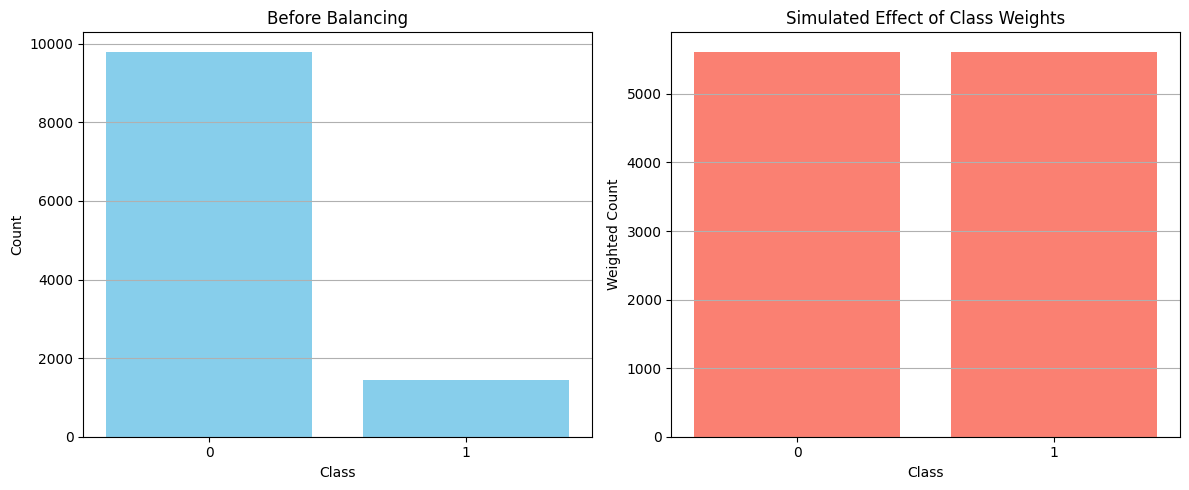

In [ ]:
classes = np.unique(df['target'])
weights = compute_class_weight(class_weight='balanced', classes=classes, y=df['target'])
class_weights = {cls: weight for cls, weight in zip(classes, weights)}

# Plotting
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# Plot before balancing
axs[0].bar(original_counts.index.astype(str), original_counts.values, color='skyblue')
axs[0].set_title("Before Balancing")
axs[0].set_xlabel("Class")
axs[0].set_ylabel("Count")
axs[0].grid(True, axis='y')

# Simulate balanced sample weights for visualization
balanced_counts = [original_counts[cls] * class_weights[cls] for cls in classes]

# Plot after applying class weights (simulated impact)
axs[1].bar([str(cls) for cls in classes], balanced_counts, color='salmon')
axs[1].set_title("Simulated Effect of Class Weights")
axs[1].set_xlabel("Class")
axs[1].set_ylabel("Weighted Count")
axs[1].grid(True, axis='y')

plt.tight_layout()
plt.show()

In [ ]:
print(class_weights)

{0: 0.573170731707317, 1: 3.9166666666666665}


In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

2025-05-24 09:47:16.633179: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1748080036.822961      35 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1748080036.878394      35 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [ ]:
# 1. Prepare features and target
X = df.drop("target", axis=1).values
y = df["target"].values

In [ ]:
# 2. Reshape for Conv1D (samples, timesteps, features)
X = X.reshape((X.shape[0], X.shape[1], 1))

In [ ]:
# 3. Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

In [ ]:
# 4. Define CNN model
model = Sequential([
    Conv1D(32, kernel_size=3, activation='relu', input_shape=(X.shape[1], 1)),
    MaxPooling1D(pool_size=2),
    Conv1D(64, kernel_size=3, activation='relu'),
    MaxPooling1D(pool_size=2),
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')  # Binary classification
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1748080110.011168      35 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [ ]:
# 5. Compile model
model.compile(optimizer=Adam(), loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
# 6. Early stopping (optional)
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

In [ ]:
# 7. Train the model using class_weights
model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=32,
    class_weight=class_weights,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 41s 181ms/step - accuracy: 0.9863 - loss: 0.0456 - val_accuracy: 0.9605 - val_loss: 0.1531
Epoch 2/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 40s 179ms/step - accuracy: 0.9966 - loss: 0.0153 - val_accuracy: 0.9722 - val_loss: 0.1514
Epoch 3/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 40s 179ms/step - accuracy: 0.9967 - loss: 0.0122 - val_accuracy: 0.9616 - val_loss: 0.1920
Epoch 4/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 40s 179ms/step - accuracy: 0.9984 - loss: 0.0149 - val_accuracy: 0.9761 - val_loss: 0.1653
Epoch 5/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 40s 179ms/step - accuracy: 0.9962 - loss: 0.0148 - val_accuracy: 0.9677 - val_loss: 0.1375
Epoch 6/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 40s 179ms/step - accuracy: 0.9974 - loss: 0.0125 - val_accuracy: 0.9755 - val_loss: 0.1447
Epoch 7/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 40s 179ms/step - accuracy: 0.9949 - loss: 0.0209 - val_accuracy: 0.9622 - val_loss: 0.1762
Epoch 8/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 40s 179ms/step - accuracy: 0.9981 - loss: 0

In [ ]:
# 8. Evaluate the model
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy:.4f}")


71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9724 - loss: 0.1190
Test Accuracy: 0.9693


In [ ]:
# 9. Classification report
y_pred = (model.predict(X_test) > 0.5).astype("int32")
print(classification_report(y_test, y_pred))

71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
              precision    recall  f1-score   support

           0       0.99      0.98      0.98      1960
           1       0.86      0.91      0.88       287

    accuracy                           0.97      2247
   macro avg       0.92      0.95      0.93      2247
weighted avg       0.97      0.97      0.97      2247

